In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten

import pyswarms as ps
from deap import base, creator, tools, algorithms
import random
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('cleandata.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

In [3]:
print("--- STATIONARITY CHECK (ADF TEST) ---")
# Ginagamit ang ADF test para malaman kung kailangan ng differencing (d parameter)
# p-value < 0.05 means stationary.
result_adf = adfuller(df['demand_kWh'].iloc[:5000])
print(f'ADF Statistic: {result_adf[0]:.4f}')
print(f'p-value: {result_adf[1]:.4f}')

--- STATIONARITY CHECK (ADF TEST) ---
ADF Statistic: -7.5266
p-value: 0.0000


<Figure size 1200x800 with 0 Axes>

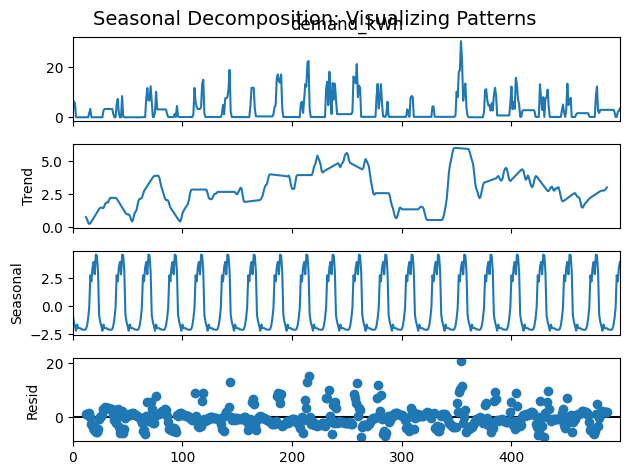

In [4]:
#Seasonal Decomposition (Visual Proof)
#Period=24 dahil hourly ang data (Daily cycle)
plt.figure(figsize=(12, 8))
decomp = seasonal_decompose(df['demand_kWh'].iloc[:500], model='additive', period=24)
decomp.plot()
plt.suptitle('Seasonal Decomposition: Visualizing Patterns\n\n', fontsize=14)
plt.show()

<Figure size 1000x400 with 0 Axes>

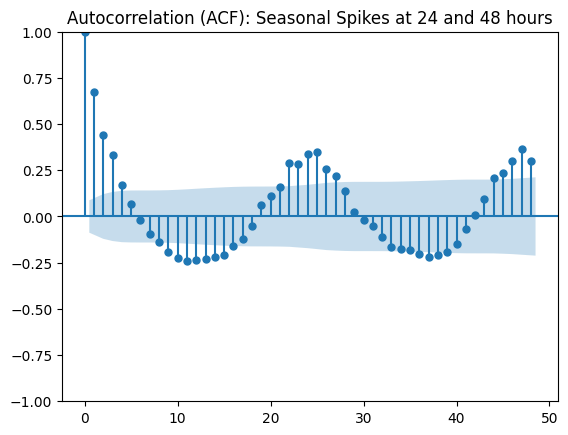

<Figure size 1000x400 with 0 Axes>

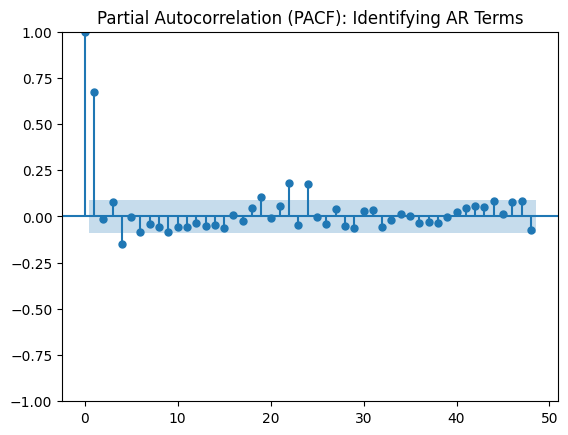

In [5]:
# ACF + PACF (eto po yung added part)
plt.figure(figsize=(10, 4))
plot_acf(df['demand_kWh'].iloc[:500], lags=48)
plt.title("Autocorrelation (ACF): Seasonal Spikes at 24 and 48 hours")
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(df['demand_kWh'].iloc[:500], lags=48, method='ywm')
plt.title("Partial Autocorrelation (PACF): Identifying AR Terms")
plt.show()

<Figure size 1000x400 with 0 Axes>

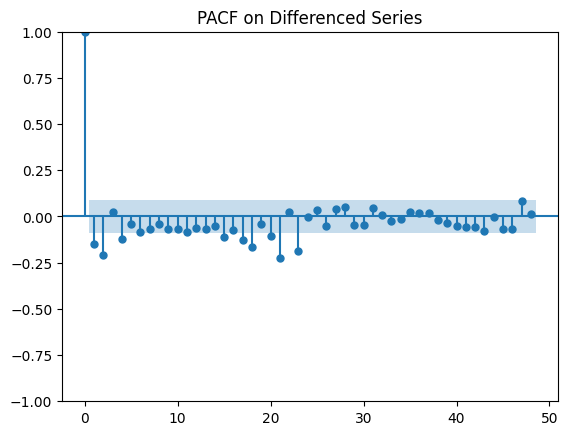

In [6]:
# PACF ON DIFFERENCED DATA
diff_series = df['demand_kWh'].diff().dropna()

plt.figure(figsize=(10, 4))
plot_pacf(diff_series.iloc[:500], lags=48, method='ywm')
plt.title("PACF on Differenced Series")
plt.show()

<Figure size 1000x400 with 0 Axes>

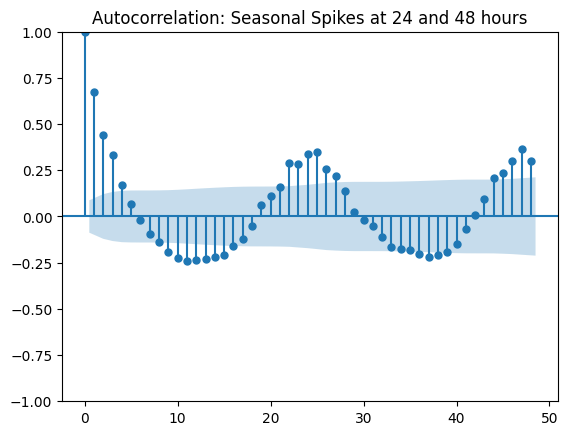

In [7]:
#ACF Plot - dito makikita ang correlation sa bawat "lag" (hour)
plt.figure(figsize=(10, 4))
plot_acf(df['demand_kWh'].iloc[:500], lags=48)
plt.title("Autocorrelation: Seasonal Spikes at 24 and 48 hours")
plt.show()

In [8]:
#data scaling and splitting
data = df[['demand_kWh']].values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

train_size = int(len(data_scaled) * 0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

In [9]:
#SARIMA MODELING (To generate Residuals)
#Sa actual run, pumili ng p,d,q, P,D,Q,s base sa results ng checks sa itaas.
print("\nFitting SARIMA Model...")
sarima_model = SARIMAX(train_data, order=(1,1,1), seasonal_order=(1,1,1,24))
sarima_results = sarima_model.fit(disp=False)

sarima_pred = sarima_results.get_forecast(steps=len(test_data)).predicted_mean
sarima_pred = sarima_pred.reshape(-1, 1)

#residuals = Actual - SARIMA Forecast (Ito ang aayusin ng TCN)
residuals = test_data - sarima_pred


Fitting SARIMA Model...


In [10]:
#TCN DATA PREPARATION
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 24
X_res, y_res = create_sequences(residuals, window)
X_res = X_res.reshape((X_res.shape[0], X_res.shape[1], 1))

In [11]:
#TCN ARCHITECTURE & FITNESS
def build_tcn(filters, kernel, lr):
    model = Sequential()
    model.add(Conv1D(filters=int(filters), kernel_size=int(kernel), activation='relu', input_shape=(window, 1)))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

def fitness_eval(filters, kernel, lr):
    #to make sure na ang kernel size ay hindi lalampas sa window size
    kernel = max(2, min(int(kernel), window))
    model = build_tcn(filters, kernel, lr)
    model.fit(X_res, y_res, epochs=3, batch_size=32, verbose=0)
    pred = model.predict(X_res, verbose=0)
    return mean_squared_error(y_res, pred)

In [12]:
#PSO HYPERPARAMETER OPTIMIZATION
print("\nRunning PSO Optimization...")
bounds = ([16, 2, 0.0001], [128, 5, 0.01])
optimizer = ps.single.GlobalBestPSO(n_particles=5, dimensions=3, options={'c1':0.5, 'c2':0.3, 'w':0.9}, bounds=bounds)

best_cost_pso, best_pos_pso = optimizer.optimize(
    lambda x: np.array([fitness_eval(p[0], p[1], p[2]) for p in x]), iters=5)

print("PSO Best Hyperparameters:", best_pos_pso)
pso_model = build_tcn(best_pos_pso[0], best_pos_pso[1], best_pos_pso[2])
pso_model.fit(X_res, y_res, epochs=10, verbose=0)

2026-04-18 04:55:36,335 - pyswarms.single.global_best - INFO - Optimize for 5 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}



Running PSO Optimization...


pyswarms.single.global_best:   0%|                                                                                                                         |0/5

2026-04-18 04:55:37,242 - tensorflow - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
pyswarms.single.global_best: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████|5/5, best_cost=0.0032
2026-04-18 04:56:48,841 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.003196440436939649, best pos: [1.05903368e+02 2.03384205e+00 1.98608729e-03]


PSO Best Hyperparameters: [1.05903368e+02 2.03384205e+00 1.98608729e-03]


In [13]:
#GA HYPERPARAMETER OPTIMIZATION
print("\nRunning GA Optimization...")
if "FitnessMin" in creator.__dict__: del creator.FitnessMin
if "Individual" in creator.__dict__: del creator.Individual

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("filters", random.randint, 16, 128)
toolbox.register("kernel", random.randint, 2, 5)
toolbox.register("lr", random.uniform, 0.0001, 0.01)
toolbox.register("individual", tools.initCycle, creator.Individual, (toolbox.filters, toolbox.kernel, toolbox.lr), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_individual(ind):
    return (fitness_eval(ind[0], ind[1], ind[2]),)

toolbox.register("evaluate", eval_individual)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=5)
algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=False)

best_ind = tools.selBest(pop, k=1)[0]
print("GA Best Hyperparameters:", best_ind)

ga_model = build_tcn(best_ind[0], best_ind[1], best_ind[2])
ga_model.fit(X_res, y_res, epochs=10, verbose=0)


Running GA Optimization...
GA Best Hyperparameters: [74.0, 3.0, 0.0007523823158950308]


In [14]:
#FINAL FORECASTS & EVALUATION
res_pso = pso_model.predict(X_res).flatten()
res_ga = ga_model.predict(X_res).flatten()

# combination ng SARIMA (Linear) at TCN (Non-linear residuals)
final_pso = sarima_pred[window:].flatten() + res_pso
final_ga = sarima_pred[window:].flatten() + res_ga
actual = test_data.flatten()[window:]

def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2*np.abs(y_pred-y_true)/(np.abs(y_true)+np.abs(y_pred)))

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape_val = smape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name} RESULTS")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | SMAPE: {smape_val:.2f}% | R2: {r2:.4f}")
    return mae, rmse, smape_val, r2

metrics_pso = evaluate("SARIMA-PSO-TCN", actual, final_pso)
metrics_ga = evaluate("SARIMA-GA-TCN", actual, final_ga)

324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

SARIMA-PSO-TCN RESULTS
MAE: 0.0397 | RMSE: 0.0566 | SMAPE: 29.34% | R2: 0.8813

SARIMA-GA-TCN RESULTS
MAE: 0.0413 | RMSE: 0.0575 | SMAPE: 36.36% | R2: 0.8772


SARIMA-PSO-TCN -> MAE: 0.04, RMSE: 0.06, SMAPE: 29.34%, R2: 0.8813
SARIMA-GA-TCN -> MAE: 0.04, RMSE: 0.06, SMAPE: 36.36%, R2: 0.8772


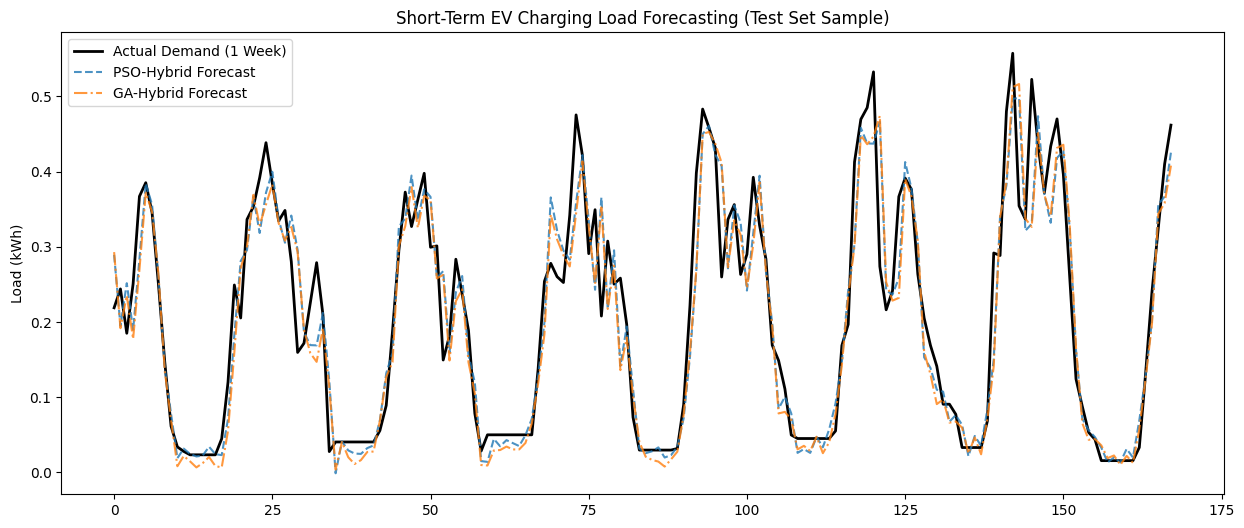

In [15]:
def report_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    s = smape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, SMAPE: {s:.2f}%, R2: {r2:.4f}")

report_metrics("SARIMA-PSO-TCN", actual, final_pso)
report_metrics("SARIMA-GA-TCN", actual, final_ga)

plt.figure(figsize=(15, 6))
plt.plot(actual[:168], label='Actual Demand (1 Week)', color='black', lw=2)
plt.plot(final_pso[:168], label='PSO-Hybrid Forecast', alpha=0.8, linestyle='--')
plt.plot(final_ga[:168], label='GA-Hybrid Forecast', alpha=0.8, linestyle='-.')
plt.ylabel('Load (kWh)')
plt.title('Short-Term EV Charging Load Forecasting (Test Set Sample)')
plt.legend()
plt.show()

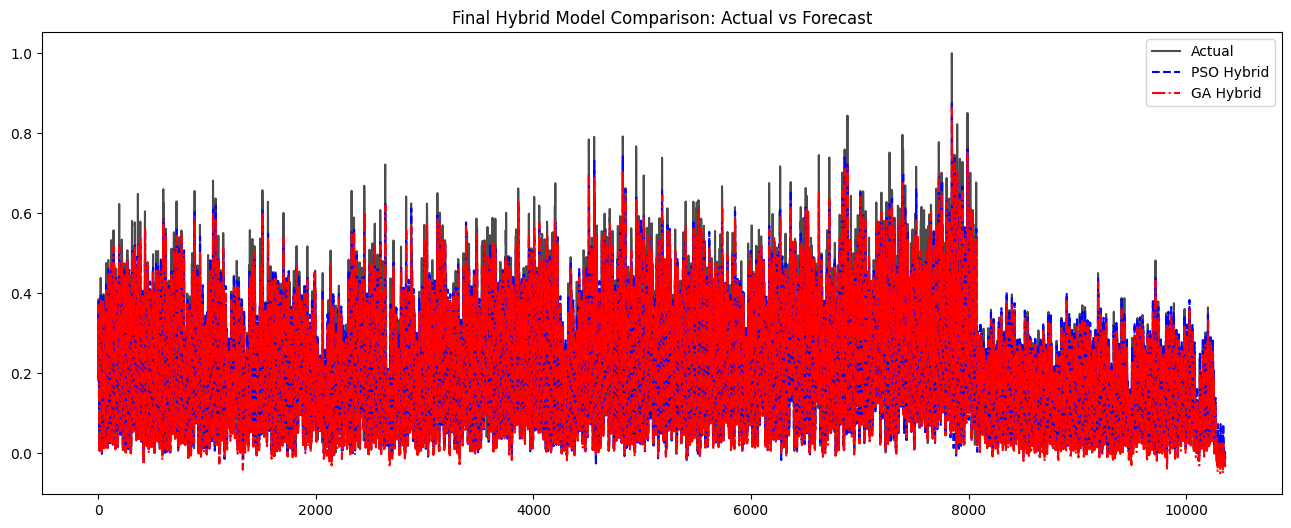

In [16]:
#FINAL VISUALIZATION
plt.figure(figsize=(16,6))
plt.plot(actual, label='Actual', color='black', alpha=0.7)
plt.plot(final_pso, label='PSO Hybrid', color='blue', linestyle='--')
plt.plot(final_ga, label='GA Hybrid', color='red', linestyle='-.')
plt.title("Final Hybrid Model Comparison: Actual vs Forecast")
plt.legend()
plt.show()